# B0_02 — Naive baseline (OHLCV, 1D, full)

Reglas fuente de verdad: `experimentos_v3/readme_experimentos_v3.md` y `experimentos_v3/PLANNING.md`.

Este notebook implementa un baseline naive para **Task B (Next-day OHLCV)** usando el dataset **1D full** y el split oficial walk-forward + holdout desde **2025-06**.

## 1) Imports

In [1]:
from __future__ import annotations

import json
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display


def to_relative(path: Path, root: Path) -> str:
    try:
        return str(path.relative_to(root))
    except ValueError:
        return str(path)

## 2) Paths y configuración

In [2]:
def find_project_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for p in [start, *start.parents]:
        if (p / "data").exists() and (p / "experimentos_v3").exists():
            return p
    raise FileNotFoundError("No se encontró el root del proyecto (esperado: carpetas 'data' y 'experimentos_v3')")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"

DATASET_NAME = "full"
TASK_NAME = "ohlcv"
MODEL_NAME = "B0_02_naive"

DATASET_PATH = DATA_DIR / f"btc_1d_features__{DATASET_NAME}.csv"
SPLIT_PATH = DATA_DIR / "_splits" / "splits_1d_walkforward_v3_holdout_from_2025_06.json"

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR = DATA_DIR / "_experiments" / TASK_NAME / MODEL_NAME / DATASET_NAME / RUN_ID
OUT_DIR.mkdir(parents=True, exist_ok=True)

{
    "project_root": ".",
    "dataset_path": to_relative(DATASET_PATH, PROJECT_ROOT),
    "split_path": to_relative(SPLIT_PATH, PROJECT_ROOT),
    "out_dir": to_relative(OUT_DIR, PROJECT_ROOT),
}

{'project_root': '.',
 'dataset_path': 'data/btc_1d_features__full.csv',
 'split_path': 'data/_splits/splits_1d_walkforward_v3_holdout_from_2025_06.json',
 'out_dir': 'data/_experiments/ohlcv/B0_02_naive/full/20260315_150316'}

## 3) Cargar dataset y definir targets

Task B evalúa sobre OHLCV a t+1.

In [3]:
def resolve_col(df: pd.DataFrame, candidates: list[str]) -> str:
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(f"No se encontró ninguna columna entre: {candidates}")


df = pd.read_csv(DATASET_PATH)

if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], utc=False)
elif "timestamp" in df.columns:
    df["date"] = pd.to_datetime(df["timestamp"], utc=False)
else:
    raise ValueError("Dataset debe incluir columna 'date' o 'timestamp'")

df = df.sort_values("date").reset_index(drop=True)

col_open = resolve_col(df, ["open"]) 
col_high = resolve_col(df, ["high"]) 
col_low = resolve_col(df, ["low"]) 
col_close = resolve_col(df, ["close"]) 
col_volume = resolve_col(df, ["volume", "vol", "volume_btc", "volume_usd"]) 

df["y_true_open_t1"] = df[col_open].shift(-1)
df["y_true_high_t1"] = df[col_high].shift(-1)
df["y_true_low_t1"] = df[col_low].shift(-1)
df["y_true_close_t1"] = df[col_close].shift(-1)
df["y_true_volume_t1"] = df[col_volume].shift(-1)

df = df.dropna(subset=["y_true_open_t1", "y_true_high_t1", "y_true_low_t1", "y_true_close_t1", "y_true_volume_t1"]).copy()

df[["date", col_open, col_high, col_low, col_close, col_volume, "y_true_open_t1", "y_true_close_t1"]].head(3)

,date,open,high,low,close,volume,y_true_open_t1,y_true_close_t1
0,2018-02-01 00:00:00+00:00,10102.082867,10169.870000,8455.000000,9010.210912,0.0,9010.210912,8810.238040
1,2018-02-02 00:00:00+00:00,9010.210912,9082.242689,7625.250000,8810.238040,0.0,8810.238040,9225.860000
2,2018-02-03 00:00:00+00:00,8810.238040,9480.773734,8164.397913,9225.860000,0.0,9225.860000,8191.321445


## 4) Split oficial (walk-forward + holdout)

In [4]:
with open(SPLIT_PATH, "r", encoding="utf-8") as f:
    split = json.load(f)

split.keys(), type(split.get("walk_forward_folds"))

(dict_keys(['created_at', 'dataset_path', 'train_start_mode', 'holdout_start_date', 'timestamp_col', 'data_range', 'walk_forward_folds', 'final_holdout']),
 list)

In [5]:
@dataclass(frozen=True)
class Period:
    name: str
    train_start: pd.Timestamp
    train_end: pd.Timestamp
    val_start: pd.Timestamp
    val_end: pd.Timestamp


def _ts(x: str) -> pd.Timestamp:
    return pd.to_datetime(x)


folds = []
for i, fold in enumerate(split.get("walk_forward_folds", []), start=1):
    folds.append(
        Period(
            name=f"fold_{i}",
            train_start=_ts(fold["train"]["start"]),
            train_end=_ts(fold["train"]["end"]),
            val_start=_ts(fold["val"]["start"]),
            val_end=_ts(fold["val"]["end"]),
        )
    )

final_holdout = split.get("final_holdout")
holdout_start = _ts(final_holdout["start"])
holdout_end = _ts(final_holdout["end"]) if "end" in final_holdout else df["date"].max()

len(folds), folds[0], (holdout_start, holdout_end)

(5,
 Period(name='fold_1', train_start=Timestamp('2014-11-10 00:00:00+0000', tz='UTC'), train_end=Timestamp('2019-12-31 23:59:59+0000', tz='UTC'), val_start=Timestamp('2020-01-01 00:00:00+0000', tz='UTC'), val_end=Timestamp('2020-12-31 23:59:59+0000', tz='UTC')),
 (Timestamp('2025-06-01 00:00:00+0000', tz='UTC'),
  Timestamp('2026-03-15 00:00:00+0000', tz='UTC')))

## 5) Métricas (Task B)

In [6]:
def mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean(np.abs(y_true - y_pred)))


def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def candle_invalid_rate(open_: np.ndarray, high: np.ndarray, low: np.ndarray, close: np.ndarray) -> float:
    high_ok = high >= np.maximum(open_, close)
    low_ok = low <= np.minimum(open_, close)
    order_ok = high >= low
    valid = high_ok & low_ok & order_ok
    return float(1.0 - np.mean(valid))


def compute_metrics_ohlcv(
    y_true: dict[str, np.ndarray],
    y_pred: dict[str, np.ndarray],
) -> dict:
    metrics = {}
    for k in ["open", "high", "low", "close", "volume"]:
        metrics[f"MAE_{k}"] = mae(y_true[k], y_pred[k])
        metrics[f"RMSE_{k}"] = rmse(y_true[k], y_pred[k])

    metrics["MAE_mean_ohlc"] = float(np.mean([metrics["MAE_open"], metrics["MAE_high"], metrics["MAE_low"], metrics["MAE_close"]]))
    metrics["RMSE_mean_ohlc"] = float(np.mean([metrics["RMSE_open"], metrics["RMSE_high"], metrics["RMSE_low"], metrics["RMSE_close"]]))

    metrics["invalid_candle_rate_pred"] = candle_invalid_rate(
        open_=y_pred["open"],
        high=y_pred["high"],
        low=y_pred["low"],
        close=y_pred["close"],
    )
    metrics["invalid_volume_rate_pred"] = float(np.mean(~np.isfinite(y_pred["volume"]) | (y_pred["volume"] < 0)))
    return metrics

## 6) Modelo naive

Baseline: predecir `ohlcv(t+1) = ohlcv(t)`.

In [7]:
def predict_naive_ohlcv(df_slice: pd.DataFrame) -> pd.DataFrame:
    out = df_slice[["date", col_open, col_high, col_low, col_close, col_volume]].copy()
    out["y_true_open_t1"] = df_slice["y_true_open_t1"].astype(float)
    out["y_true_high_t1"] = df_slice["y_true_high_t1"].astype(float)
    out["y_true_low_t1"] = df_slice["y_true_low_t1"].astype(float)
    out["y_true_close_t1"] = df_slice["y_true_close_t1"].astype(float)
    out["y_true_volume_t1"] = df_slice["y_true_volume_t1"].astype(float)

    out["y_pred_open_t1"] = out[col_open].astype(float)
    out["y_pred_high_t1"] = out[col_high].astype(float)
    out["y_pred_low_t1"] = out[col_low].astype(float)
    out["y_pred_close_t1"] = out[col_close].astype(float)
    out["y_pred_volume_t1"] = out[col_volume].astype(float)
    return out

## 7) Walk-forward folds + holdout (métricas)

Anti-leakage: no se ajusta nada con validación/holdout.

In [8]:
def slice_by_date(df: pd.DataFrame, start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    m = (df["date"] >= start) & (df["date"] <= end)
    return df.loc[m].copy()


results = {
    "meta": {
        "task": TASK_NAME,
        "model": MODEL_NAME,
        "dataset": DATASET_NAME,
        "run_id": RUN_ID,
        "dataset_path": to_relative(DATASET_PATH, PROJECT_ROOT),
        "split_path": to_relative(SPLIT_PATH, PROJECT_ROOT),
        "target": "ohlcv(t+1) (baseline: last value ohlcv(t))",
        "columns": {
            "open": col_open,
            "high": col_high,
            "low": col_low,
            "close": col_close,
            "volume": col_volume,
        },
    },
    "folds": [],
    "holdout": None,
}

for p in folds:
    df_val = slice_by_date(df, p.val_start, p.val_end)
    pred_val = predict_naive_ohlcv(df_val)

    metrics = compute_metrics_ohlcv(
        y_true={
            "open": pred_val["y_true_open_t1"].to_numpy(dtype=float),
            "high": pred_val["y_true_high_t1"].to_numpy(dtype=float),
            "low": pred_val["y_true_low_t1"].to_numpy(dtype=float),
            "close": pred_val["y_true_close_t1"].to_numpy(dtype=float),
            "volume": pred_val["y_true_volume_t1"].to_numpy(dtype=float),
        },
        y_pred={
            "open": pred_val["y_pred_open_t1"].to_numpy(dtype=float),
            "high": pred_val["y_pred_high_t1"].to_numpy(dtype=float),
            "low": pred_val["y_pred_low_t1"].to_numpy(dtype=float),
            "close": pred_val["y_pred_close_t1"].to_numpy(dtype=float),
            "volume": pred_val["y_pred_volume_t1"].to_numpy(dtype=float),
        },
    )

    results["folds"].append(
        {
            "name": p.name,
            "train": {"start": str(p.train_start.date()), "end": str(p.train_end.date())},
            "val": {"start": str(p.val_start.date()), "end": str(p.val_end.date())},
            "n_val": int(len(pred_val)),
            "metrics_ohlcv": metrics,
        }
    )

df_holdout = slice_by_date(df, holdout_start, holdout_end)
pred_holdout = predict_naive_ohlcv(df_holdout)

metrics_holdout = compute_metrics_ohlcv(
    y_true={
        "open": pred_holdout["y_true_open_t1"].to_numpy(dtype=float),
        "high": pred_holdout["y_true_high_t1"].to_numpy(dtype=float),
        "low": pred_holdout["y_true_low_t1"].to_numpy(dtype=float),
        "close": pred_holdout["y_true_close_t1"].to_numpy(dtype=float),
        "volume": pred_holdout["y_true_volume_t1"].to_numpy(dtype=float),
    },
    y_pred={
        "open": pred_holdout["y_pred_open_t1"].to_numpy(dtype=float),
        "high": pred_holdout["y_pred_high_t1"].to_numpy(dtype=float),
        "low": pred_holdout["y_pred_low_t1"].to_numpy(dtype=float),
        "close": pred_holdout["y_pred_close_t1"].to_numpy(dtype=float),
        "volume": pred_holdout["y_pred_volume_t1"].to_numpy(dtype=float),
    },
)

results["holdout"] = {
    "period": {"start": str(holdout_start.date()), "end": str(holdout_end.date())},
    "n_holdout": int(len(pred_holdout)),
    "metrics_ohlcv": metrics_holdout,
}

results["holdout"], results["folds"][0]["metrics_ohlcv"]

({'period': {'start': '2025-06-01', 'end': '2026-03-15'},
  'n_holdout': 287,
  'metrics_ohlcv': {'MAE_open': 1511.0620082726045,
   'RMSE_open': 2084.7272839167226,
   'MAE_high': 1333.7167965187762,
   'RMSE_high': 1803.7085044441874,
   'MAE_low': 1421.5758245490924,
   'RMSE_low': 2099.091627054069,
   'MAE_close': 1509.5479776816933,
   'RMSE_close': 2084.132916985275,
   'MAE_volume': 9969.856813871114,
   'RMSE_volume': 14090.871120760961,
   'MAE_mean_ohlc': 1443.9756517555415,
   'RMSE_mean_ohlc': 2017.9150831000636,
   'invalid_candle_rate_pred': 0.0,
   'invalid_volume_rate_pred': 0.0}},
 {'MAE_open': 267.6695689972678,
  'RMSE_open': 426.4897998852632,
  'MAE_high': 241.5847181557377,
  'RMSE_high': 402.8959056012073,
  'MAE_low': 237.53351913934424,
  'RMSE_low': 393.0325571274999,
  'MAE_close': 268.7957014262296,
  'RMSE_close': 427.0546385646741,
  'MAE_volume': 0.0,
  'RMSE_volume': 0.0,
  'MAE_mean_ohlc': 253.89587692964483,
  'RMSE_mean_ohlc': 412.36822529466116,
  '

## 8) Guardar artefactos requeridos

In [9]:
metrics_path = OUT_DIR / "metrics.json"
pred_holdout_path = OUT_DIR / "pred_holdout.csv"

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

pred_cols = [
    "date",
    "y_true_open_t1",
    "y_pred_open_t1",
    "y_true_high_t1",
    "y_pred_high_t1",
    "y_true_low_t1",
    "y_pred_low_t1",
    "y_true_close_t1",
    "y_pred_close_t1",
    "y_true_volume_t1",
    "y_pred_volume_t1",
]
pred_holdout[pred_cols].to_csv(pred_holdout_path, index=False)

to_relative(metrics_path, PROJECT_ROOT), to_relative(pred_holdout_path, PROJECT_ROOT)

('data/_experiments/ohlcv/B0_02_naive/full/20260315_150316/metrics.json',
 'data/_experiments/ohlcv/B0_02_naive/full/20260315_150316/pred_holdout.csv')

## 9) Figuras requeridas (holdout)

Para Task B, se grafican (1) **velas japonesas** (real vs predicción) y (2) **curva de close** (real vs predicción) en el holdout.

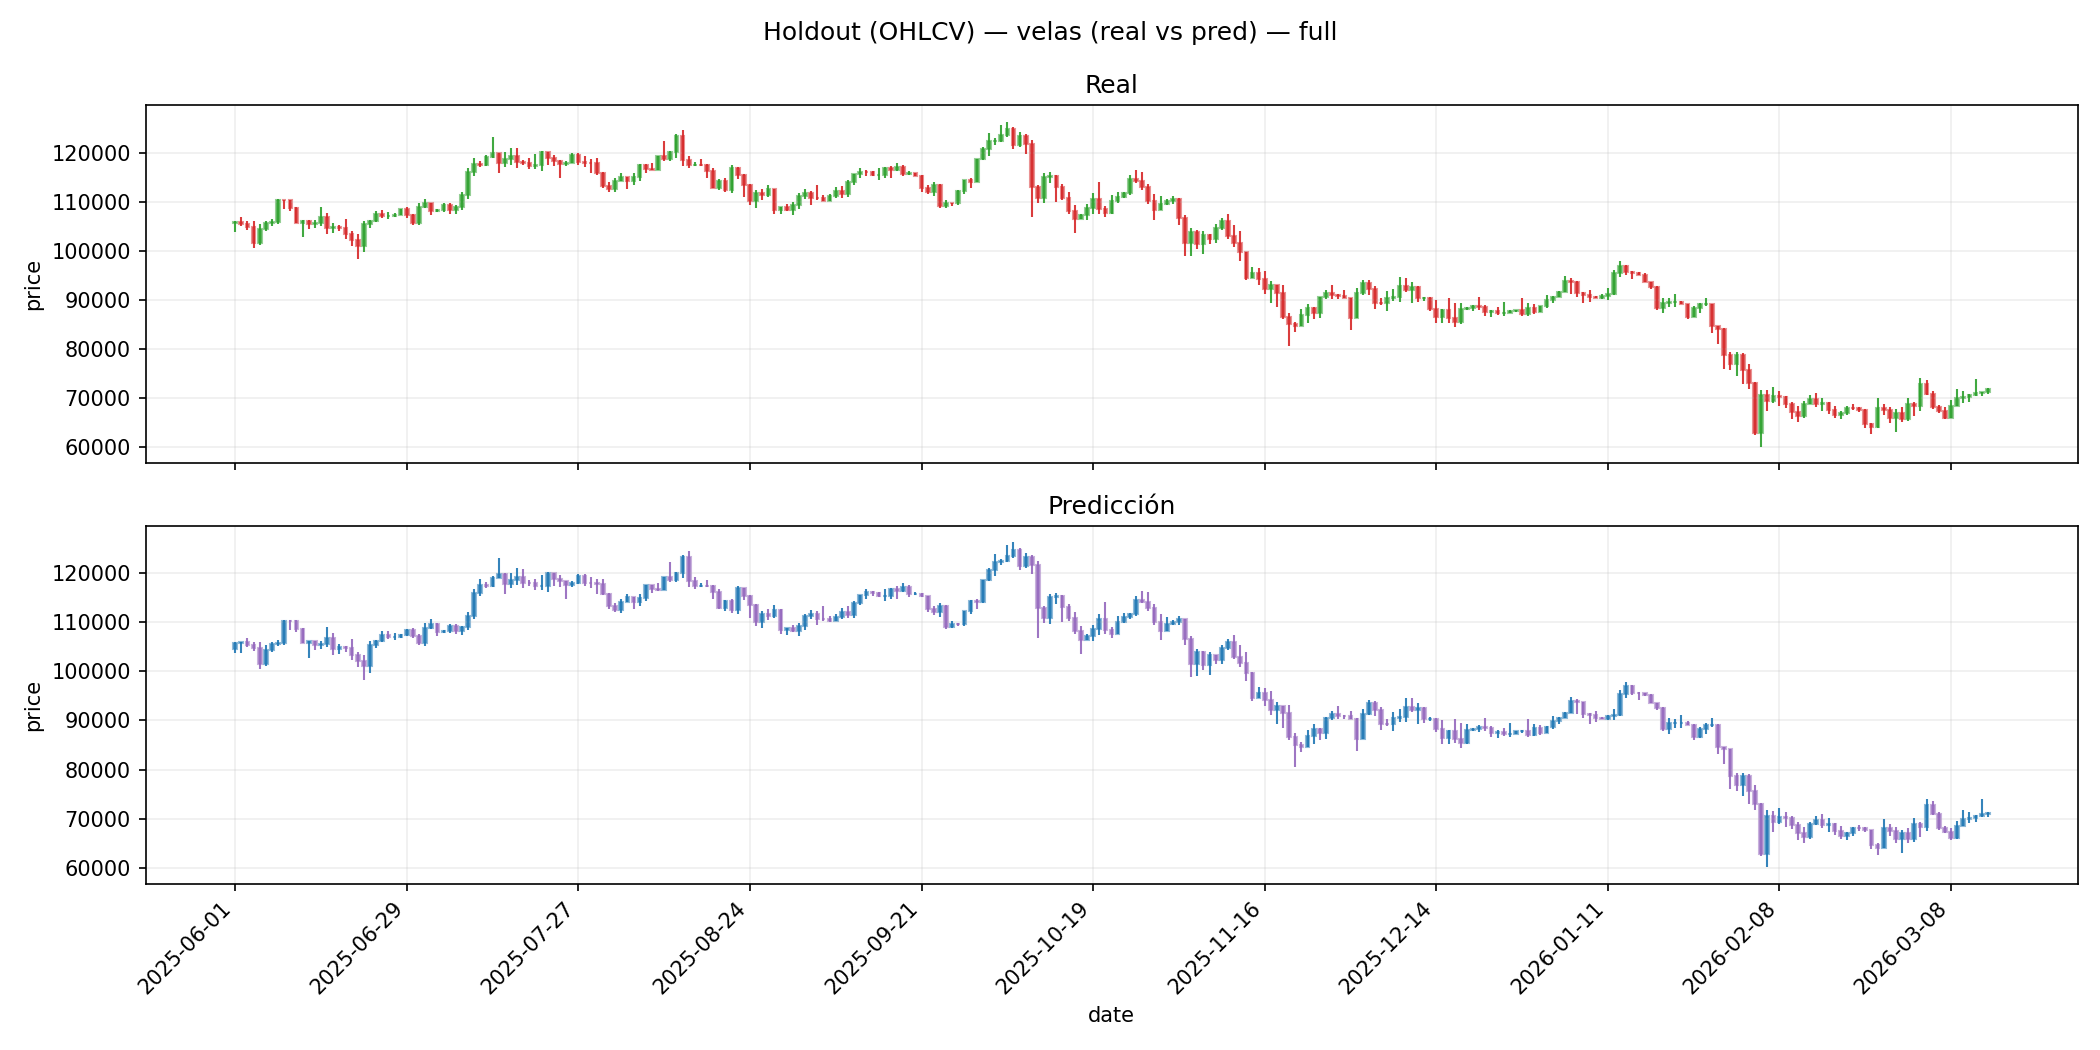

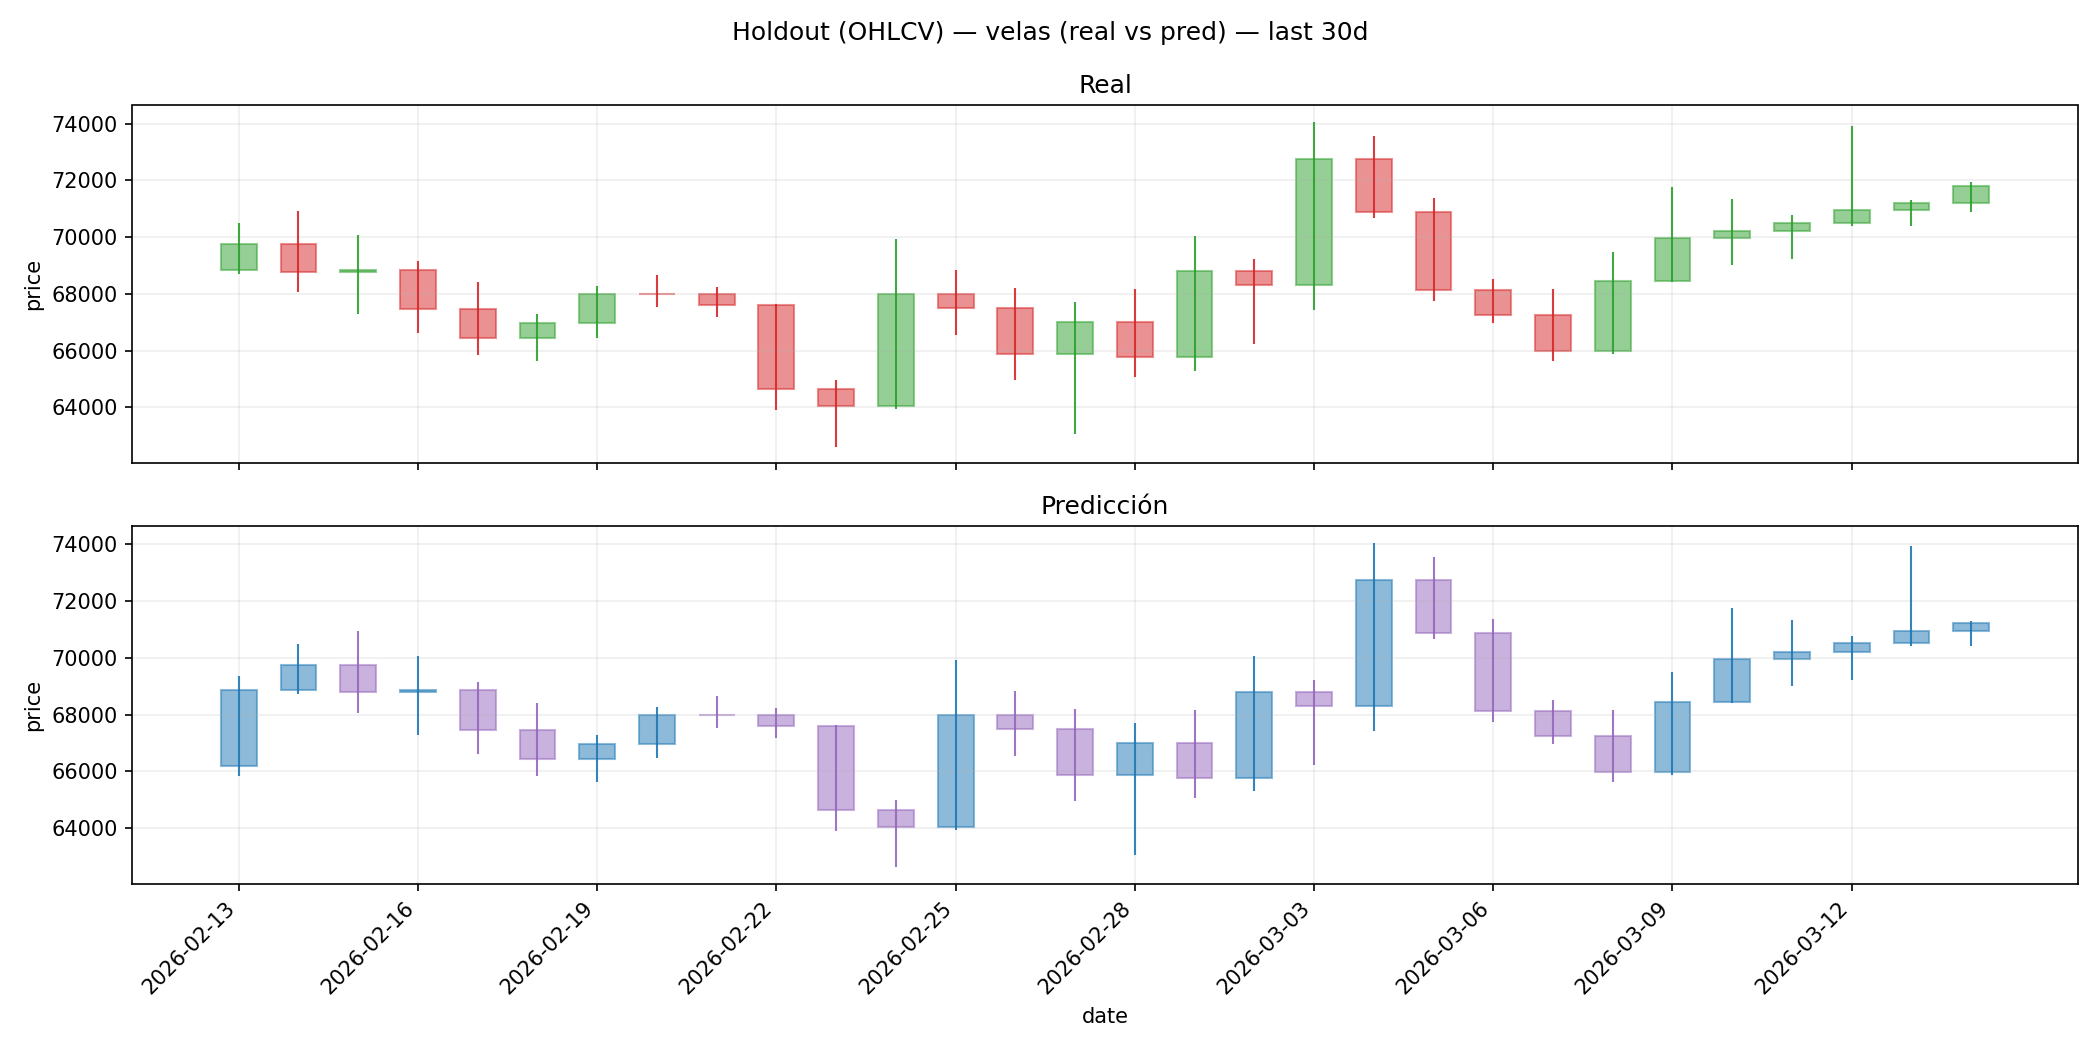

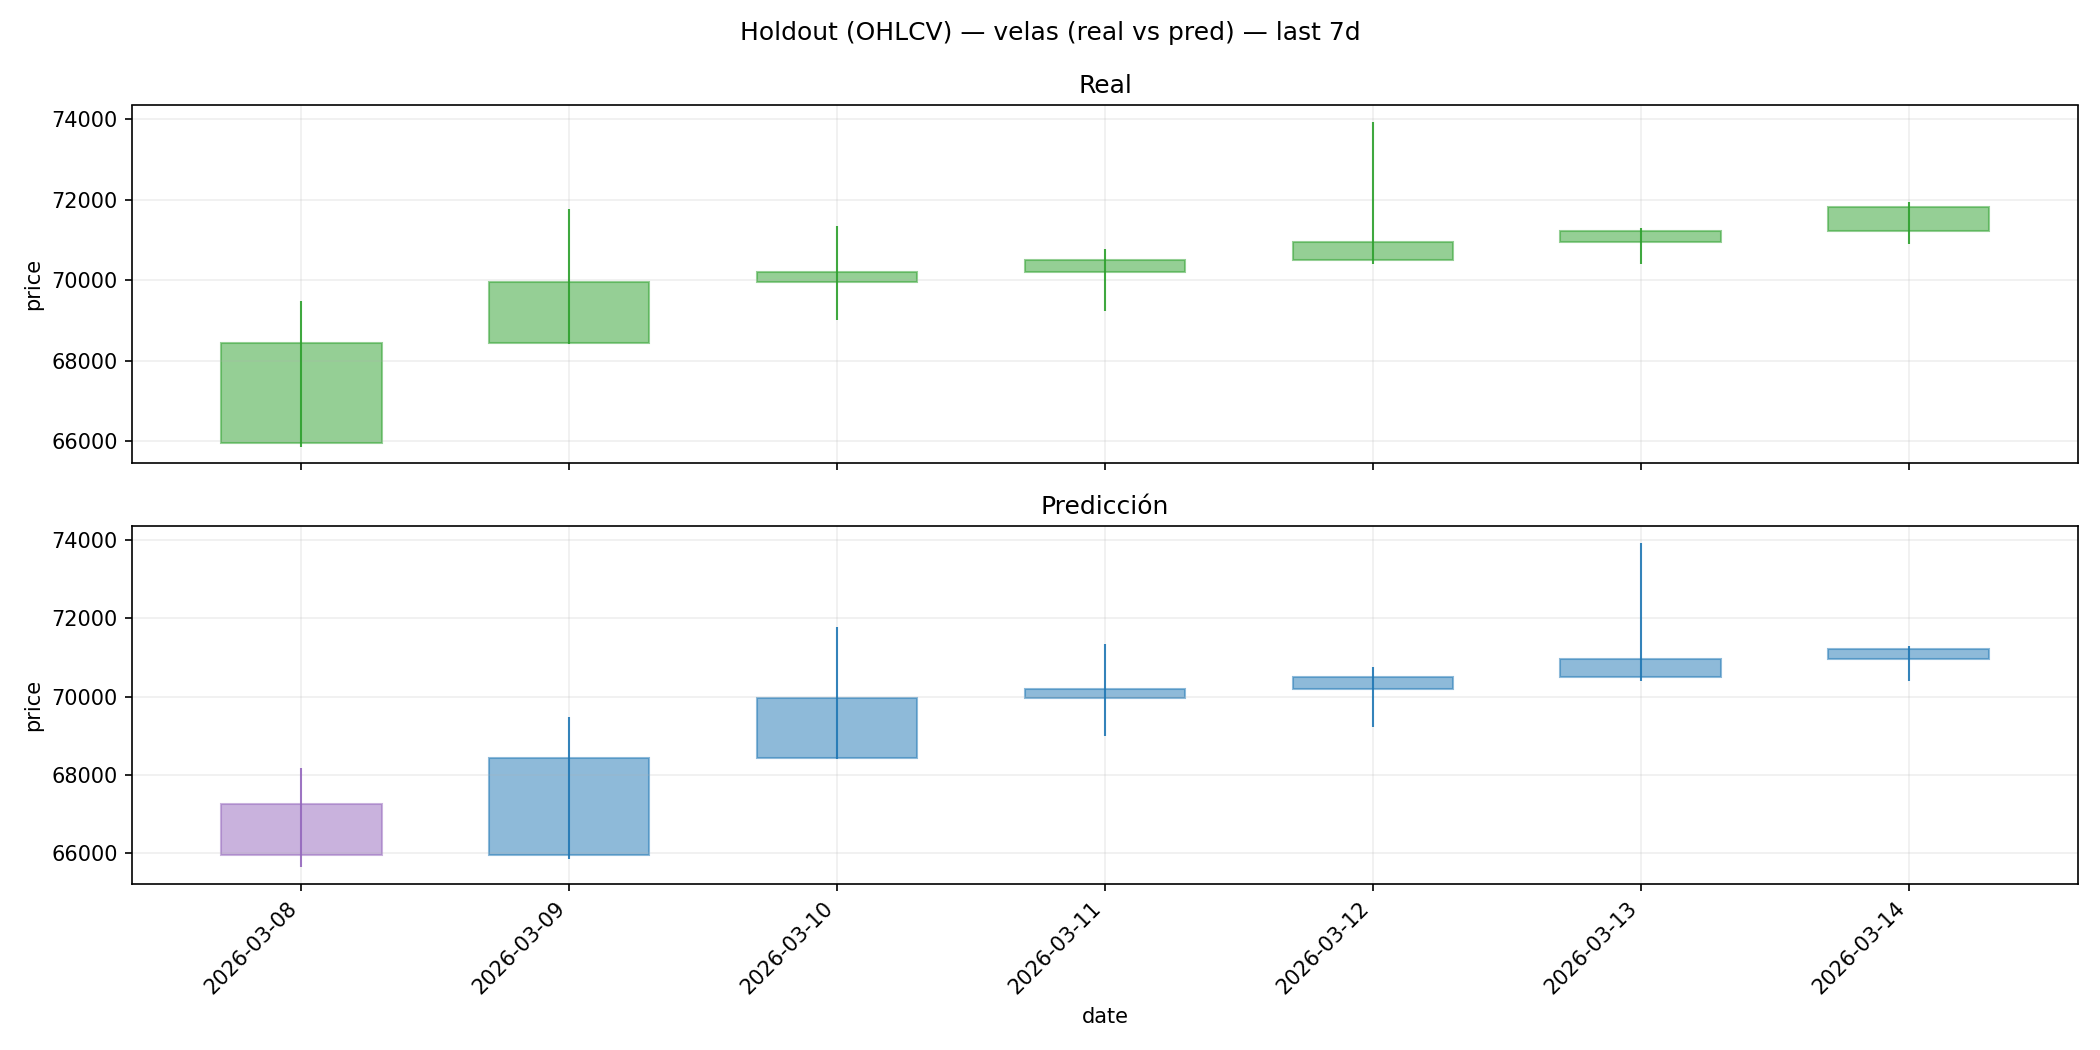

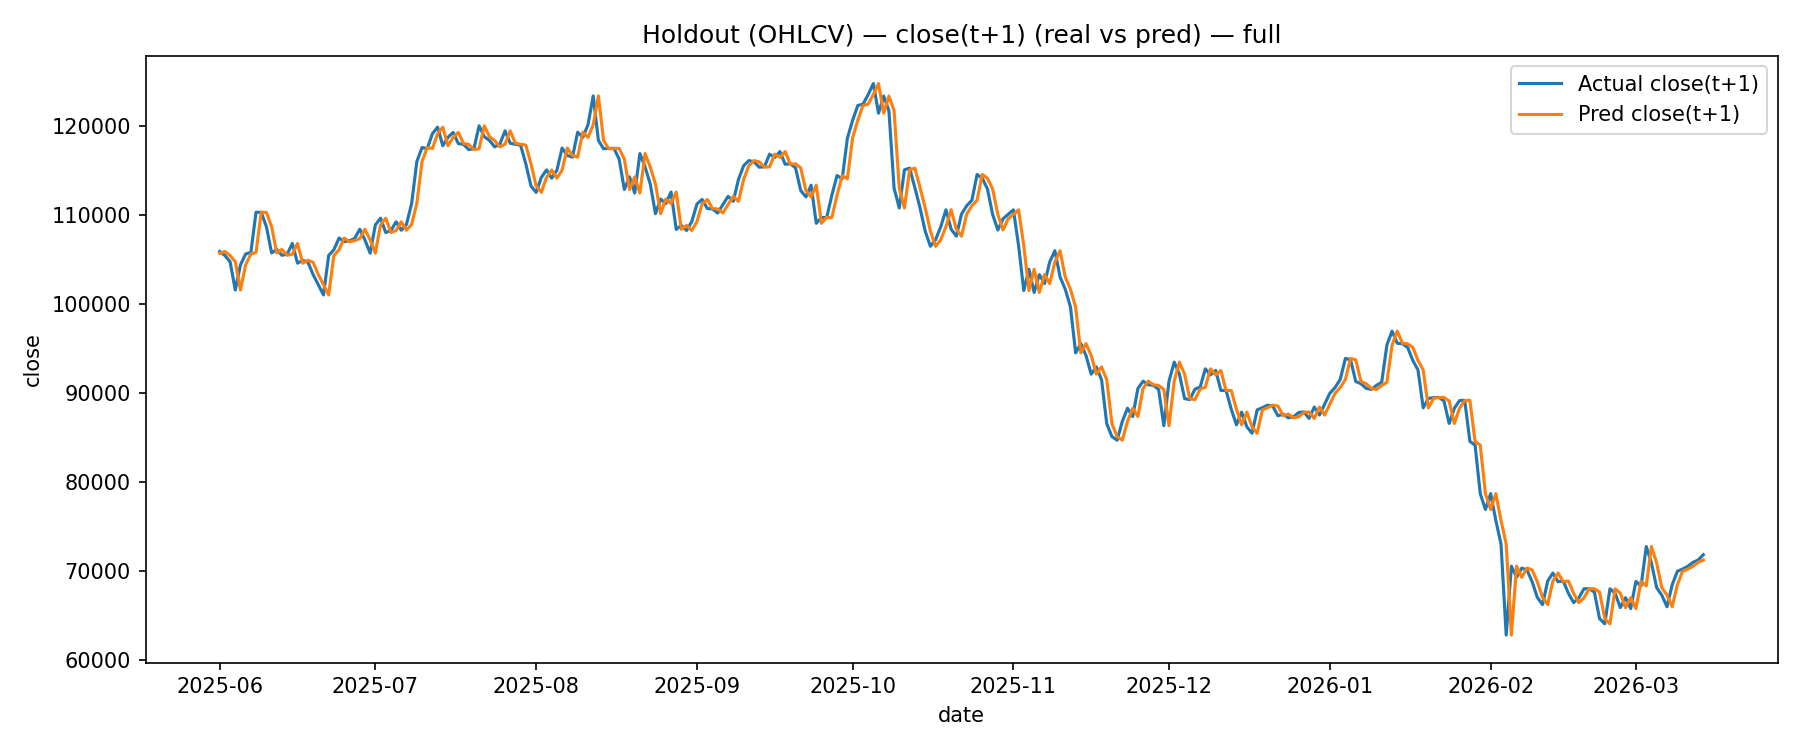

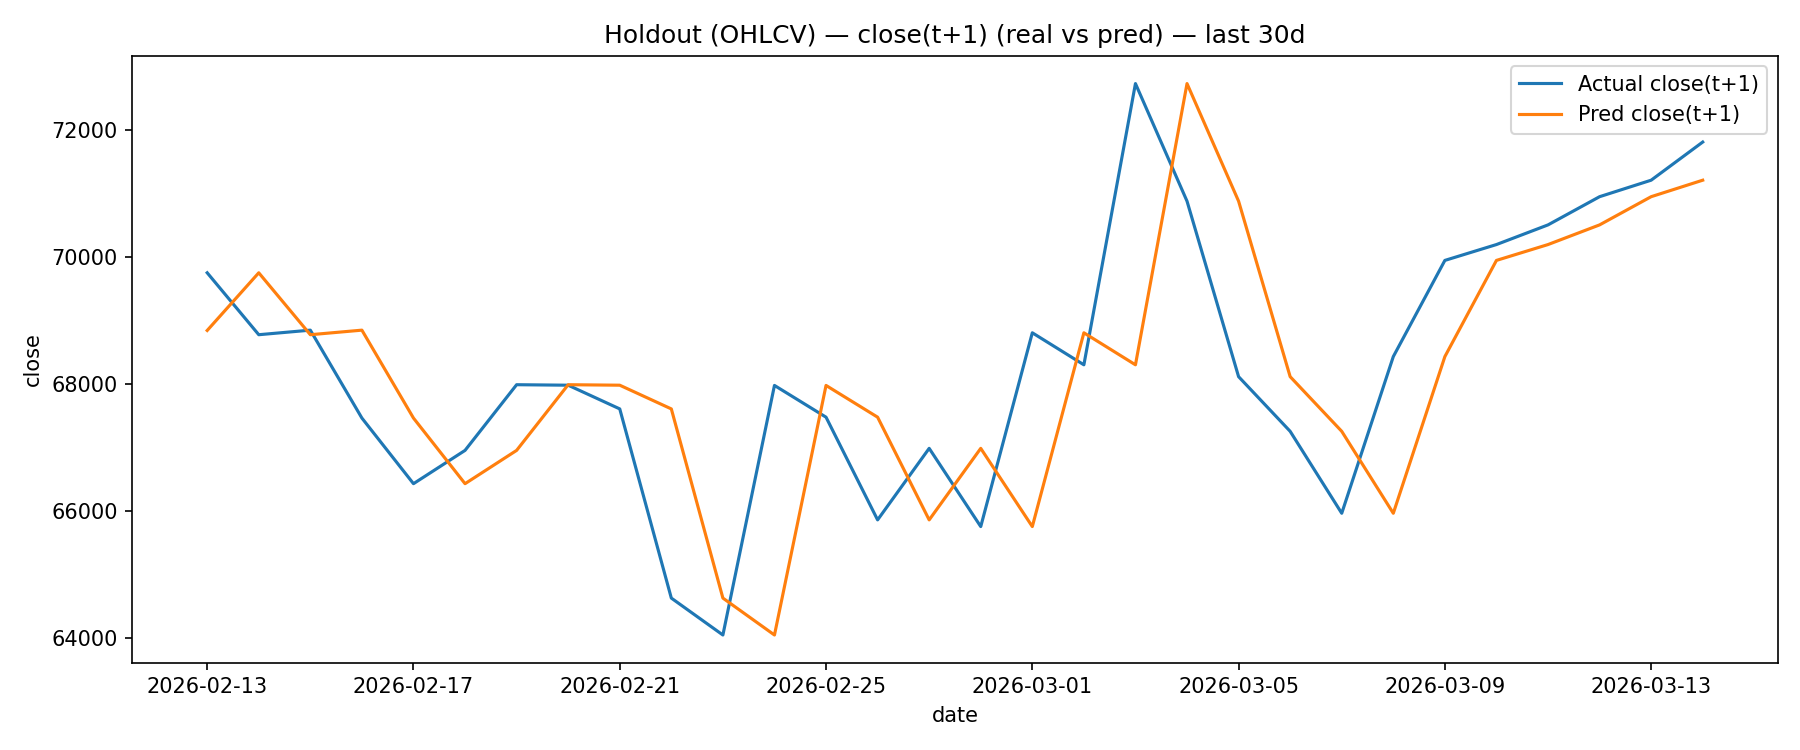

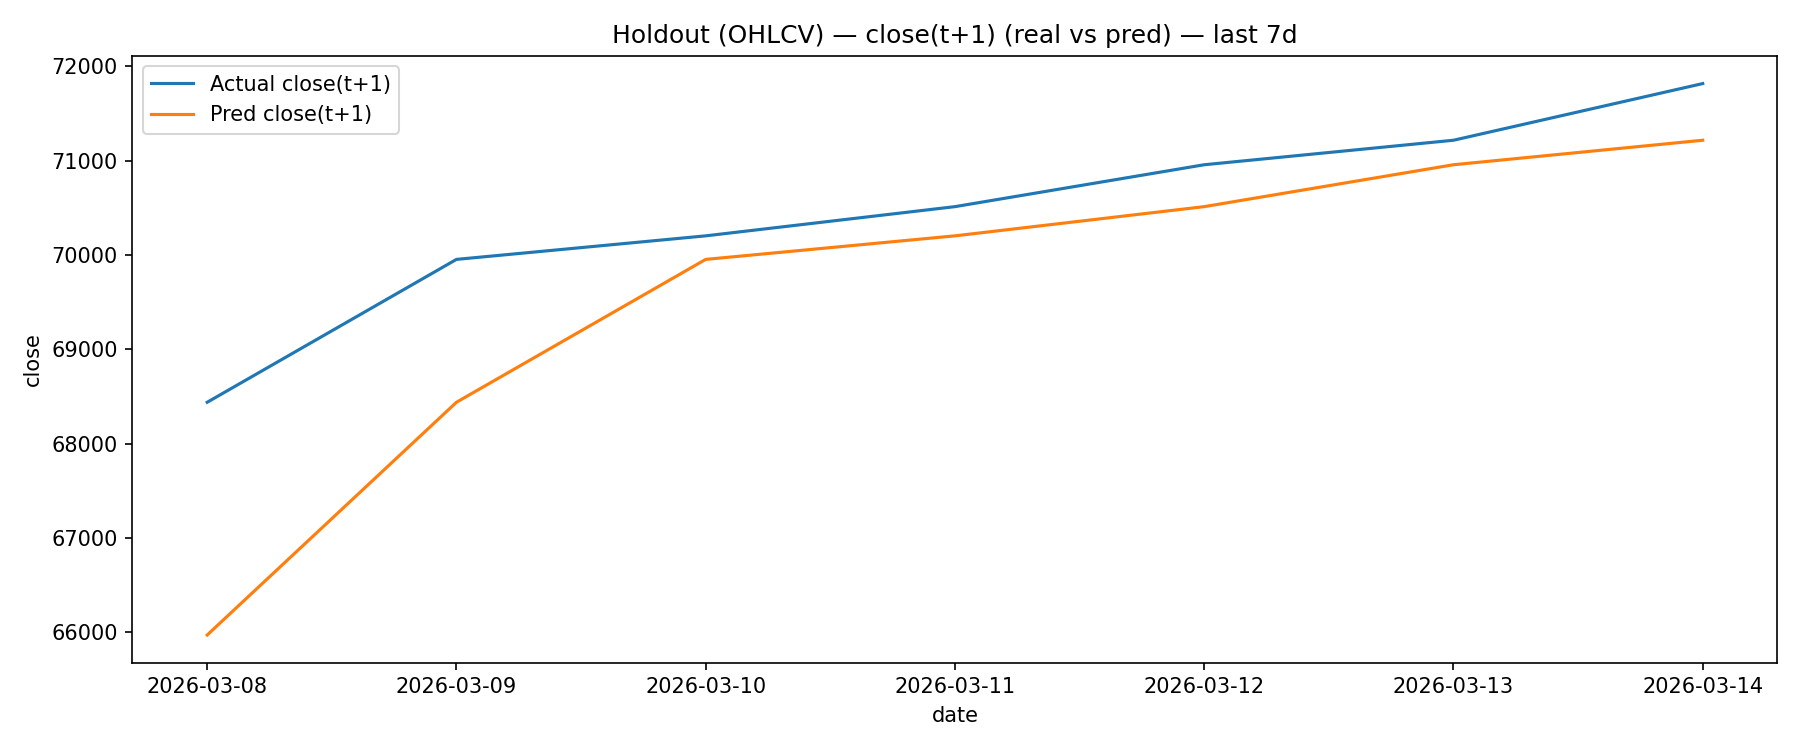

('data/_experiments/ohlcv/B0_02_naive/full/20260315_150316/fig_holdout_full.png',
 'data/_experiments/ohlcv/B0_02_naive/full/20260315_150316/fig_holdout_last30d.png',
 'data/_experiments/ohlcv/B0_02_naive/full/20260315_150316/fig_holdout_last7d.png',
 'data/_experiments/ohlcv/B0_02_naive/full/20260315_150316/fig_holdout_close_full.png',
 'data/_experiments/ohlcv/B0_02_naive/full/20260315_150316/fig_holdout_close_last30d.png',
 'data/_experiments/ohlcv/B0_02_naive/full/20260315_150316/fig_holdout_close_last7d.png')

In [10]:
def plot_holdout_candles(pred: pd.DataFrame, title: str, out_path: Path, last_n: int | None = None) -> None:
    from matplotlib.patches import Rectangle

    d = pred.copy()
    if last_n is not None:
        d = d.tail(last_n)

    d = d.reset_index(drop=True)
    dates = pd.to_datetime(d["date"])
    x = np.arange(len(dates), dtype=float)

    def _plot_candles(ax, o: np.ndarray, h: np.ndarray, l: np.ndarray, c: np.ndarray, *, up: str, down: str) -> None:
        width = 0.6
        for i in range(len(o)):
            color = up if c[i] >= o[i] else down
            ax.vlines(x[i], l[i], h[i], color=color, linewidth=1.0, alpha=0.9)
            body_low = min(o[i], c[i])
            body_h = abs(c[i] - o[i])
            if body_h == 0:
                body_h = 1e-9
            ax.add_patch(
                Rectangle(
                    (x[i] - width / 2.0, body_low),
                    width,
                    body_h,
                    facecolor=color,
                    edgecolor=color,
                    alpha=0.5,
                )
            )

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    fig.suptitle(title)

    _plot_candles(
        ax1,
        d["y_true_open_t1"].to_numpy(dtype=float),
        d["y_true_high_t1"].to_numpy(dtype=float),
        d["y_true_low_t1"].to_numpy(dtype=float),
        d["y_true_close_t1"].to_numpy(dtype=float),
        up="#2ca02c",
        down="#d62728",
    )
    ax1.set_title("Real")
    ax1.set_ylabel("price")
    ax1.grid(True, alpha=0.2)

    _plot_candles(
        ax2,
        d["y_pred_open_t1"].to_numpy(dtype=float),
        d["y_pred_high_t1"].to_numpy(dtype=float),
        d["y_pred_low_t1"].to_numpy(dtype=float),
        d["y_pred_close_t1"].to_numpy(dtype=float),
        up="#1f77b4",
        down="#9467bd",
    )
    ax2.set_title("Predicción")
    ax2.set_ylabel("price")
    ax2.grid(True, alpha=0.2)

    labels = [str(d.date()) for d in dates]
    step = max(1, len(labels) // 10)
    ax2.set_xticks(x[::step])
    ax2.set_xticklabels(labels[::step], rotation=45, ha="right")
    ax2.set_xlabel("date")

    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    display(Image(filename=str(out_path)))
    plt.close()


def plot_holdout_close_lines(pred: pd.DataFrame, title: str, out_path: Path, last_n: int | None = None) -> None:
    d = pred.copy()
    if last_n is not None:
        d = d.tail(last_n)

    plt.figure(figsize=(12, 5))
    plt.plot(d["date"], d["y_true_close_t1"], label="Actual close(t+1)")
    plt.plot(d["date"], d["y_pred_close_t1"], label="Pred close(t+1)")
    plt.title(title)
    plt.xlabel("date")
    plt.ylabel("close")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    display(Image(filename=str(out_path)))
    plt.close()


fig_full = OUT_DIR / "fig_holdout_full.png"
fig_last30 = OUT_DIR / "fig_holdout_last30d.png"
fig_last7 = OUT_DIR / "fig_holdout_last7d.png"

fig_close_full = OUT_DIR / "fig_holdout_close_full.png"
fig_close_last30 = OUT_DIR / "fig_holdout_close_last30d.png"
fig_close_last7 = OUT_DIR / "fig_holdout_close_last7d.png"

plot_holdout_candles(pred_holdout, "Holdout (OHLCV) — velas (real vs pred) — full", fig_full, last_n=None)
plot_holdout_candles(pred_holdout, "Holdout (OHLCV) — velas (real vs pred) — last 30d", fig_last30, last_n=30)
plot_holdout_candles(pred_holdout, "Holdout (OHLCV) — velas (real vs pred) — last 7d", fig_last7, last_n=7)

plot_holdout_close_lines(pred_holdout, "Holdout (OHLCV) — close(t+1) (real vs pred) — full", fig_close_full, last_n=None)
plot_holdout_close_lines(pred_holdout, "Holdout (OHLCV) — close(t+1) (real vs pred) — last 30d", fig_close_last30, last_n=30)
plot_holdout_close_lines(pred_holdout, "Holdout (OHLCV) — close(t+1) (real vs pred) — last 7d", fig_close_last7, last_n=7)

(
    to_relative(fig_full, PROJECT_ROOT),
    to_relative(fig_last30, PROJECT_ROOT),
    to_relative(fig_last7, PROJECT_ROOT),
    to_relative(fig_close_full, PROJECT_ROOT),
    to_relative(fig_close_last30, PROJECT_ROOT),
    to_relative(fig_close_last7, PROJECT_ROOT),
)

## 10) Figura timeline folds + holdout

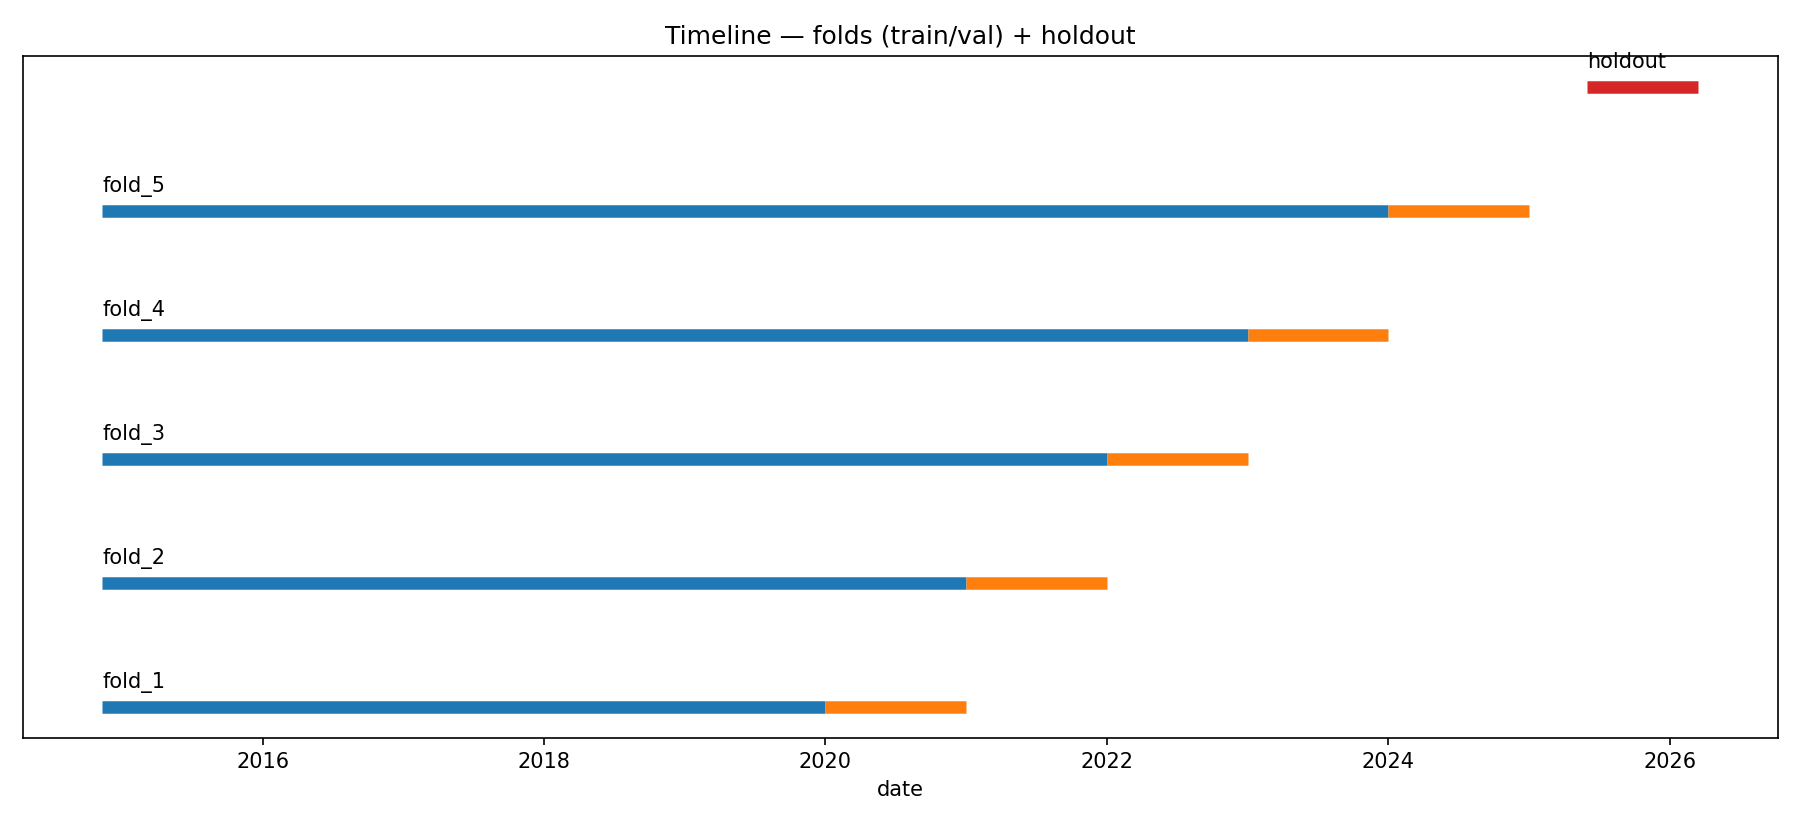

'data/_experiments/ohlcv/B0_02_naive/full/20260315_150316/fig_timeline_folds_holdout.png'

In [11]:
def plot_timeline(folds: list[Period], holdout_start: pd.Timestamp, holdout_end: pd.Timestamp, out_path: Path) -> None:
    plt.figure(figsize=(12, 3 + 0.5 * len(folds)))

    y = 0
    for p in folds:
        plt.hlines(y, p.train_start, p.train_end, colors="#1f77b4", linewidth=6)
        plt.hlines(y, p.val_start, p.val_end, colors="#ff7f0e", linewidth=6)
        plt.text(p.train_start, y + 0.15, p.name)
        y += 1

    plt.hlines(y, holdout_start, holdout_end, colors="#d62728", linewidth=6)
    plt.text(holdout_start, y + 0.15, "holdout")

    plt.yticks([])
    plt.xlabel("date")
    plt.title("Timeline — folds (train/val) + holdout")
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    display(Image(filename=str(out_path)))
    plt.close()


fig_timeline = OUT_DIR / "fig_timeline_folds_holdout.png"
plot_timeline(folds, holdout_start, holdout_end, fig_timeline)
to_relative(fig_timeline, PROJECT_ROOT)

## 11) Resumen

In [12]:
rows = []
for f in results["folds"]:
    r = {"split": f["name"], **f["metrics_ohlcv"], "split_type": "val"}
    rows.append(r)

hold = results["holdout"]
rows.append({"split": "holdout", **hold["metrics_ohlcv"], "split_type": "holdout"})

pd.DataFrame(rows)

,split,MAE_open,RMSE_open,MAE_high,RMSE_high,MAE_low,RMSE_low,MAE_close,RMSE_close,MAE_volume,RMSE_volume,MAE_mean_ohlc,RMSE_mean_ohlc,invalid_candle_rate_pred,invalid_volume_rate_pred,split_type
0,fold_1,267.669569,426.489800,241.584718,402.895906,237.533519,393.032557,268.795701,427.054639,0.000000,0.000000,253.895877,412.368225,0.013661,0.0,val
1,fold_2,1441.972425,1926.293733,1212.944528,1649.304425,1476.135617,2089.406374,1445.016451,1927.834927,0.000000,0.000000,1394.017255,1898.209865,0.002740,0.0,val
2,fold_3,662.019222,1020.163024,590.965196,916.458130,616.674706,1001.640821,658.062236,1017.020019,0.000000,0.000000,631.930340,988.820498,0.005479,0.0,val
3,fold_4,440.505714,658.664157,430.857767,663.821266,380.479622,595.417118,445.536143,666.295177,0.000000,0.000000,424.344811,646.049430,0.021918,0.0,val
4,fold_5,1330.850139,1857.500620,1103.016220,1597.478725,1269.189118,1747.157481,1330.508340,1856.974971,905.098060,6150.530541,1258.390954,1764.777949,0.021918,0.0,val
5,holdout,1511.062008,2084.727284,1333.716797,1803.708504,1421.575825,2099.091627,1509.547978,2084.132917,9969.856814,14090.871121,1443.975652,2017.915083,0.000000,0.0,holdout
